In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from collections import Counter

In [32]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['training.1600000.processed.noemoticon.csv']


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = os.path.join(
    path,
    "training.1600000.processed.noemoticon.csv"
)

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (1600000, 6)
   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [34]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
[0, 1, 2, 3, 4, 5]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   0       1600000 non-null  int64 
 1   1       1600000 non-null  int64 
 2   2       1600000 non-null  object
 3   3       1600000 non-null  object
 4   4       1600000 non-null  object
 5   5       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [35]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64


In [36]:
print(df.columns.tolist())
print(df.head())

[0, 1, 2, 3, 4, 5]
   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['training.1600000.processed.noemoticon.csv']


In [38]:
csv_files = [
    f for f in os.listdir(path)
    if f.lower().endswith(".csv")
]

print("CSV files found:")
print(csv_files)

CSV files found:
['training.1600000.processed.noemoticon.csv']


In [39]:
df.columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

print(df.columns.tolist())

['sentiment', 'id', 'date', 'query', 'user', 'text']


In [40]:
print(" Sentiment Distribution")
print(df["sentiment"].value_counts())

 Sentiment Distribution
sentiment
0    800000
4    800000
Name: count, dtype: int64


In [41]:
def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol
    text = re.sub(r"#", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [42]:
df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head(10))

                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   
5                      @Kwesidei not the whole crew    
6                                        Need a hug    
7  @LOLTrish hey  long time no see! Yes.. Rains a...   
8               @Tatiana_K nope they didn't have it    
9                          @twittera que me muera ?    

                                          clean_text  
0  a thats a bummer you shoulda got david carr of...  
1  is upset that he cant update his facebook by t...  
2  i dived many times for the ball managed to sav...  
3     my whole body feels itchy and like its on fire  
4  no its not behaving at all im mad why am i her...  
5                                 not the whole crew 

In [43]:
df = df[df["clean_text"].str.strip() != ""]

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (1596303, 7)


In [44]:
def extract_hashtags(text):
    return re.findall(r"#(\w+)", str(text).lower())

In [45]:
df["hashtags"] = df["text"].apply(extract_hashtags)

print(df[["text", "hashtags"]].head(10))

                                                text hashtags
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...       []
1  is upset that he can't update his Facebook by ...       []
2  @Kenichan I dived many times for the ball. Man...       []
3    my whole body feels itchy and like its on fire        []
4  @nationwideclass no, it's not behaving at all....       []
5                      @Kwesidei not the whole crew        []
6                                        Need a hug        []
7  @LOLTrish hey  long time no see! Yes.. Rains a...       []
8               @Tatiana_K nope they didn't have it        []
9                          @twittera que me muera ?        []


In [46]:
from collections import Counter

all_hashtags = []

for hashtags in df["hashtags"]:
    all_hashtags.extend(hashtags)

hashtag_counts = Counter(all_hashtags)

print("Top 20 Trending Hashtags:")

for hashtag, count in hashtag_counts.most_common(20):
    print("#" + hashtag, count)

Top 20 Trending Hashtags:
#followfriday 2640
#fb 1786
#ff 985
#squarespace 941
#1 519
#iranelection 518
#seb 499
#musicmonday 422
#fail 363
#2 341
#asot400 333
#iphone 318
#bsb 314
#iremember 299
#myweakness 272
#marsiscoming 260
#f1 258
#e3 257
#bgt 246
#mcflyforgermany 230


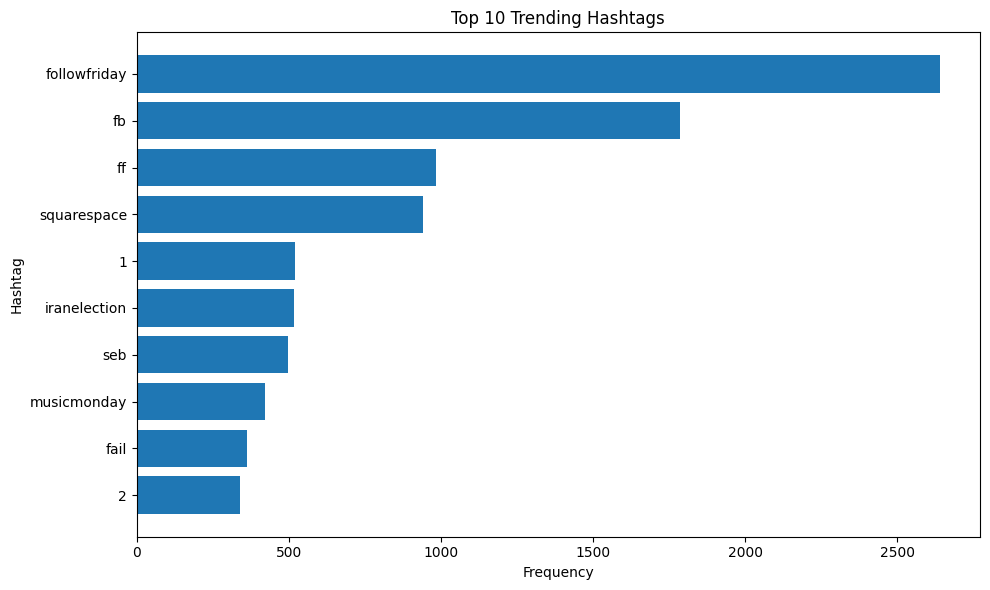

In [47]:
top_hashtags = pd.DataFrame(
    hashtag_counts.most_common(10),
    columns=["Hashtag", "Count"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_hashtags["Hashtag"],
    top_hashtags["Count"]
)

plt.title("Top 10 Trending Hashtags")
plt.xlabel("Frequency")
plt.ylabel("Hashtag")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [48]:
all_text = " ".join(
    df["clean_text"].astype(str)
)

words = all_text.split()

print("Total words:", len(words))

Total words: 19803555


In [49]:
word_counts = Counter(words)

print("Most Common Words:")

for word, count in word_counts.most_common(20):
    print(word, count)

Most Common Words:
i 751302
to 564591
the 520095
a 382780
my 314119
and 298466
you 270159
is 236031
it 230928
for 215724
in 214388
of 183448
im 178401
on 167122
me 160214
so 150857
have 144550
that 141356
but 127522
just 125070


In [50]:
stop_words = {
    "the", "is", "a", "an", "and", "or", "to",
    "of", "in", "on", "for", "with", "this",
    "that", "it", "i", "you", "my", "me",
    "we", "our", "are", "was", "were", "be",
    "have", "has", "had", "but", "not", "so",
    "at", "from", "as", "just", "im", "your",
    "they", "them", "their", "he", "she", "his",
    "her", "will", "would", "can", "could"
}

In [51]:
filtered_words = [
    word
    for word in words
    if word not in stop_words
    and len(word) > 2
]

interest_counts = Counter(filtered_words)

print("Top Public Interests:")

for word, count in interest_counts.most_common(20):
    print(word, count)

Top Public Interests:
its 108595
now 90413
good 89424
day 84818
get 81603
all 80720
out 80540
like 77781
dont 67306
today 64639
too 64225
going 64100
love 63488
cant 62893
work 62823
got 60903
time 56127
back 55991
lol 55215
what 52232


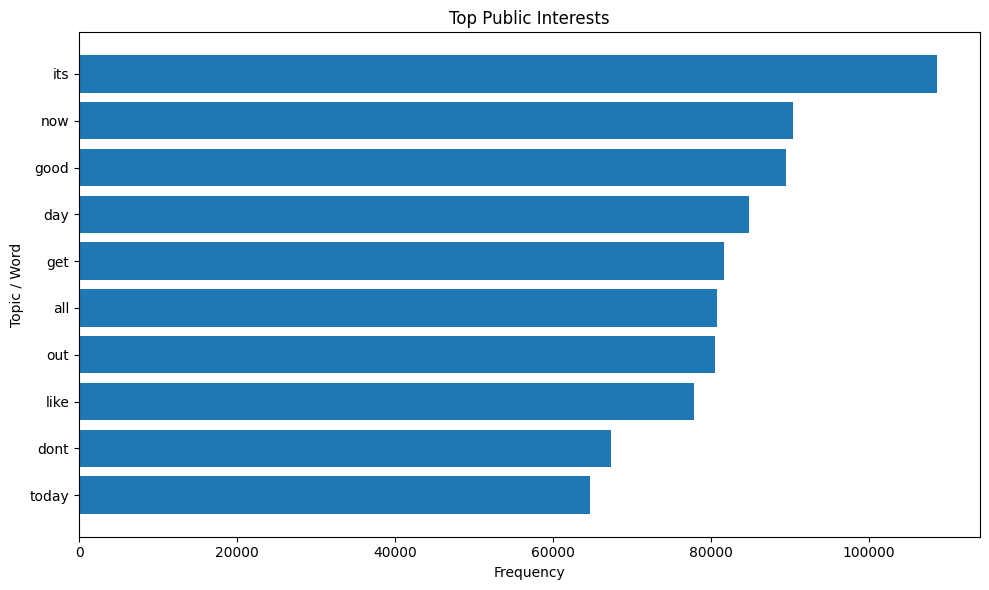

In [52]:
top_interests = pd.DataFrame(
    interest_counts.most_common(10),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_interests["Word"],
    top_interests["Frequency"]
)

plt.title("Top Public Interests")
plt.xlabel("Frequency")
plt.ylabel("Topic / Word")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [54]:
print(df.columns.tolist())
print(df.head())

['sentiment', 'id', 'date', 'query', 'user', 'text', 'clean_text', 'hashtags']
   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  \
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1    scotthamilton  is upset that he can't update his Facebook by ...   
2         mattycus  @Kenichan I dived many times for the ball. Man...   
3          ElleCTF    my whole body feels itchy and like its on fire    
4           Karoli  @nationwideclass no, it's not behaving at all....   

                                          clean_text hashtags  
0  a that

In [56]:
df["sentiment_label"] = df["sentiment"].map({
    0: "Negative",
    4: "Positive"
})

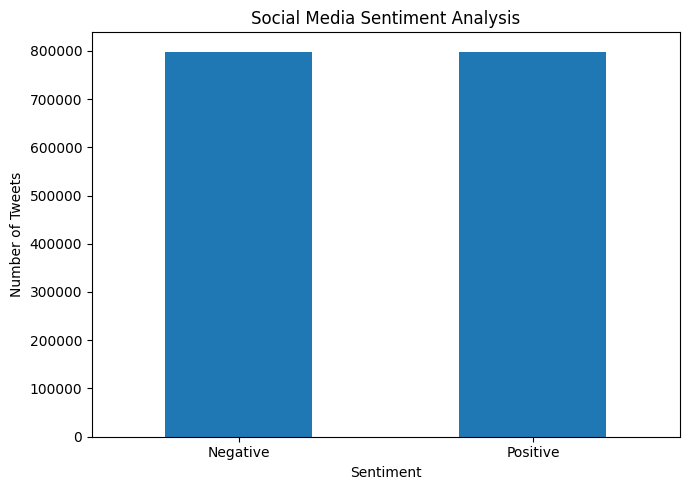

In [57]:
df["sentiment_label"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Social Media Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [59]:
sentiment_counts = df["sentiment_label"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

Sentiment Counts:
sentiment_label
Negative    798319
Positive    797984
Name: count, dtype: int64


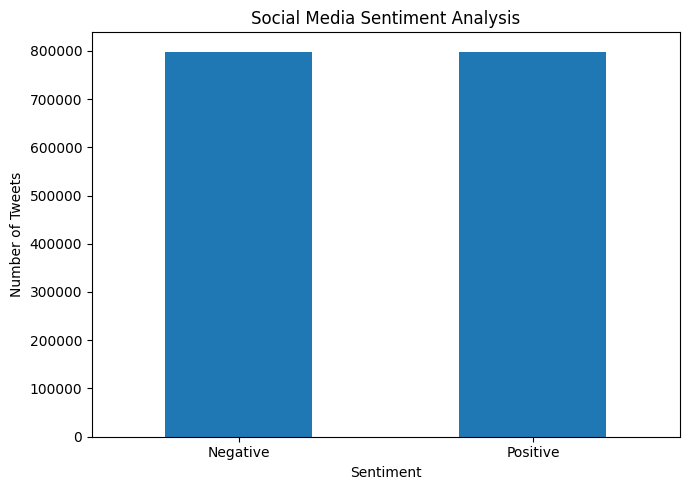

In [60]:
plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Social Media Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [61]:
sentiment_percentage = (
    df["sentiment_label"]
    .value_counts(normalize=True)
    * 100
)

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
sentiment_label
Negative    50.01
Positive    49.99
Name: proportion, dtype: float64
